In [12]:
import numpy as np
import spatialmath as sm
import spatialmath.base as smb
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [41]:
# 读取 .npz 文件
data = np.load('DataWrite/local_solve_0.npz')
# data = np.load('DataWrite/local_solve_average_0.npz')
# data = np.load('DataWrite/local_solve_nostretch_0.npz')
# data = np.load('DataWrite/local_solve_nostretch_new_0.npz')

# 访问各个数组
distance_vec1 = data['distance_vec1']
distance_vec2 = data['distance_vec2']
distance_theta1 = data['distance_theta1']
distance_theta2 = data['distance_theta2']
ele_quat_theta1 = data['ele_quat_theta1']
ele_quat_theta2 = data['ele_quat_theta2']

# 关闭文件以释放资源
data.close()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

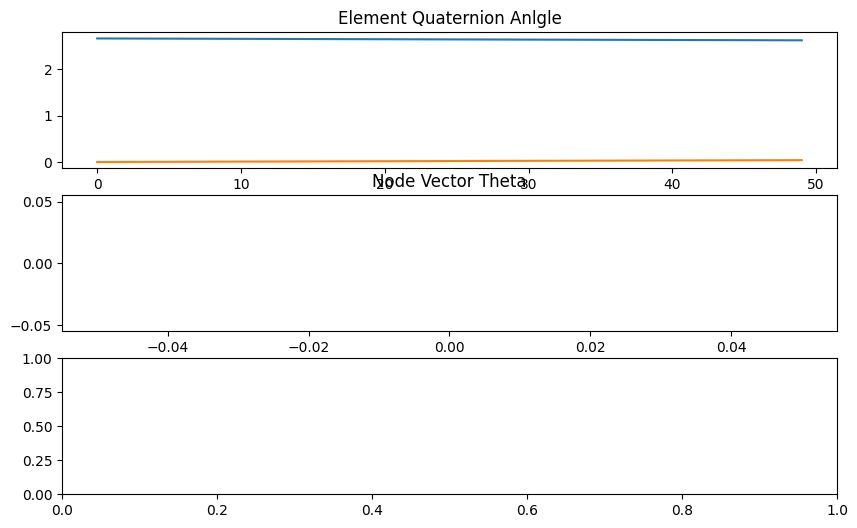

In [36]:
# 2D版本的数据plot
fig = plt.figure(figsize=(10, 6), dpi=100)
gs = GridSpec(3, 1, figure=fig)

ax_ele_theta = fig.add_subplot(gs[0])
ax_ele_theta.plot(ele_quat_theta1)
ax_ele_theta.plot(ele_quat_theta2)
ax_ele_theta.set_title('Element Quaternion Anlgle')

ax_distance_theta = fig.add_subplot(gs[1])
ax_distance_theta.plot(distance_theta1)
ax_distance_theta.plot(distance_theta2)
ax_distance_theta.set_title('Node Vector Theta')

ax_distance_vec = fig.add_subplot(gs[2])
ax_distance_vec.plot(distance_vec1[:, 1])
ax_distance_vec.plot(distance_vec2[:, 1])
ax_distance_vec.set_title('Node Vector')

axs = [ax_ele_theta, ax_distance_theta, ax_distance_vec]
for ax in axs:
    ax.set_xlim([-1, 200])
    ax.grid(True)

plt.tight_layout()

IndexError: index 2 is out of bounds for axis 1 with size 2

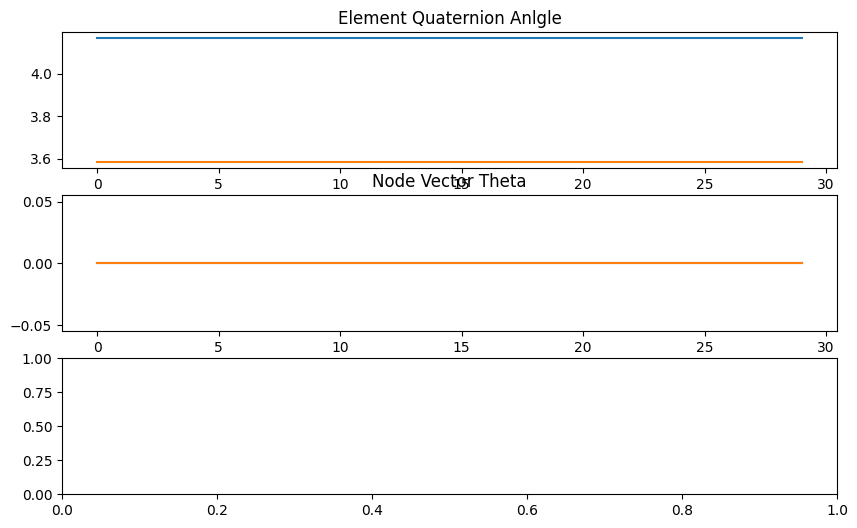

In [6]:
# 3D版本的数据plot
fig = plt.figure(figsize=(10, 6), dpi=100)
gs = GridSpec(3, 1, figure=fig)

ax_ele_theta = fig.add_subplot(gs[0])
ax_ele_theta.plot(ele_quat_theta1)
ax_ele_theta.plot(ele_quat_theta2)
ax_ele_theta.set_title('Element Quaternion Anlgle')

ax_distance_theta = fig.add_subplot(gs[1])
ax_distance_theta.plot(distance_theta1)
ax_distance_theta.plot(distance_theta2)
ax_distance_theta.set_title('Node Vector Theta')

ax_distance_vec = fig.add_subplot(gs[2])
ax_distance_vec.plot(distance_vec1[:, 2])
ax_distance_vec.plot(distance_vec2[:, 2])
ax_distance_vec.set_title('Node Vector')

axs = [ax_ele_theta, ax_distance_theta, ax_distance_vec]
for ax in axs:
    ax.set_xlim([-1, 200])
    ax.grid(True)

plt.tight_layout()

In [131]:
def find_convergence_step(array, epsilon):
    # Calculate the difference between consecutive elements
    differences = np.abs(np.diff(array))
    
    # Find the first index where the difference is less than epsilon
    for i, diff in enumerate(differences):
        if diff < epsilon:
            return i + 1  # Return the iteration step (index + 1)
    
    return len(array)  # Return the total number of steps if no convergence

In [109]:
epsilon = 1.e-2

print(find_convergence_step(ele_quat_theta1, epsilon))
print(find_convergence_step(ele_quat_theta2, epsilon))

54
52


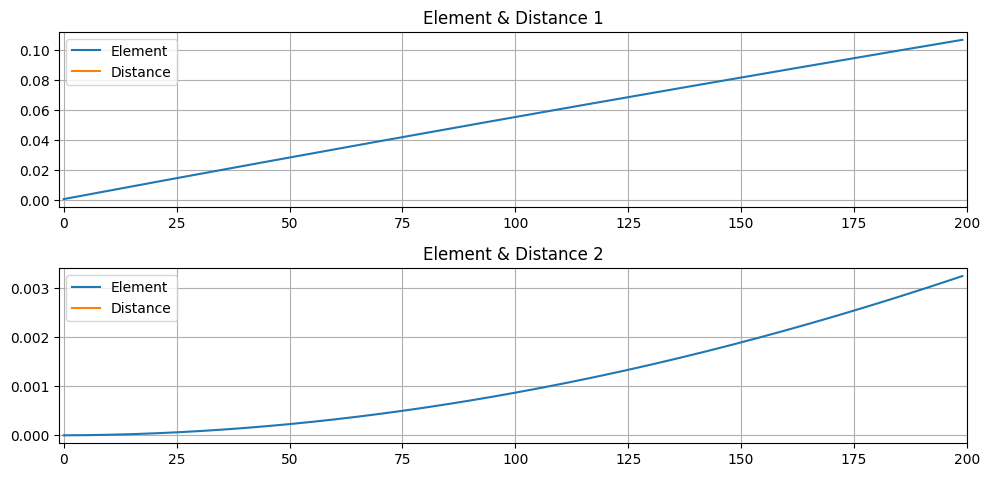

In [42]:
# 3D版本下的Element方向和Distance方向的plot
fig = plt.figure(figsize=(10, 7), dpi=100)
gs = GridSpec(3, 1, figure=fig)

ax_ele_theta = fig.add_subplot(gs[0])
ax_ele_theta.plot(ele_quat_theta1, label='Element')
ax_ele_theta.plot(distance_theta1, label='Distance')
ax_ele_theta.set_title('Element & Distance 1')

ax_distance_theta = fig.add_subplot(gs[1])
ax_distance_theta.plot(ele_quat_theta2, label='Element')
ax_distance_theta.plot(distance_theta2, label='Distance')
ax_distance_theta.set_title('Element & Distance 2')

axs = [ax_ele_theta, ax_distance_theta]
for ax in axs:
    # ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    ax.set_xlim([-1, 200])
    ax.legend()
    ax.grid(True)

plt.tight_layout()